# C5.4 Networks Mini-project
#### _(Candidate 1509403)_

In this notebook, we provide numerical simulations to verify the analytical expressions derived in my mini-project submission. 

## The All-or-none Recursive Graph model
The graph model works as follows:
<br>At time $t = 0$, we begin with a system with a single node, say $G_1$. At each subsequent time step, we simulate a recursive growth process. At time $t = n + 1$, we select a target node (chosen uniformly at random) from $G_n$, say $v$. A new node, say $v^*$, is attached to the target node. We then complete the copying step:
<br>•	With probability $1 - p$, $v^*$ attaches only to the target node.
<br>•	With probability $p$, it connects to all neighbours of the target node, say $x_i$ for $1 \leq i \leq k_v$ where $k_v$ is the degree of the target node.

We therefore implement this model as follows. Note that in most of my analysis, we work with the number of nodes, $n$, as the quantity that we iterate over (the dependent variable in our recurrence relations). However, most of the algorithms and graphs will instead work with $t$ as a quantity.

In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import scipy.special as sp
rng = np.random.default_rng(seed=None)

In [2]:
import pickle
import os

In [3]:
#function to create a new edge, occurs each timestep
def newEdgeAON(G, p, rand):
    if G == None: #if no graph, we begin with G_1, the graph at t = 0
        G = nx.Graph()
        G.add_node(1)
    n = G.number_of_nodes()
    
    if rand == None: #note that when generating a graph G_{n_max}, it is faster to generate all the rv first, so I added this functionality
        rand = rng.binomial(1, p, size=(1, 1)) #chooses whether copying occurs via Bernoulli rv, probability p
        
    t = np.random.choice(G.nodes()) #chooses target
    G.add_node(n + 1)
    
    if rand == 1:
        neighbours = list(G.neighbors(t))
        for nb in neighbours:
            G.add_edge(n + 1, nb) #adds edges to neighbours if copying occurs
    G.add_edge(n + 1,t) #adds edge to the target afterwards
    return G

In [4]:
#function to generate a new graph G_n, with t = n - 1 (graph at t=0 is G_1)
def aonGen(G, p, t):
    randArray = rng.binomial(1, p, size=(t, 1)) #generates random variables beforehand
    for i in range(0, t):
        newEdgeAON(G, p, randArray[i]) #simulates t timesteps of the model
    return G

In [5]:
#generates the default graph
G_init = nx.Graph()
G_init.add_node(1)

Example graph for $p = 0.4, t = 20$.

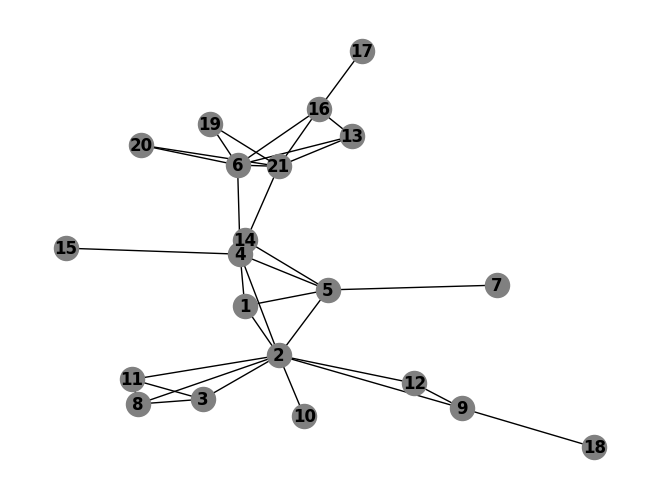

In [6]:
p = 0.4
t = 20
G_example = aonGen(G_init.copy(), p, t)
nx.draw(G_example, with_labels=True, font_weight='bold', node_color='grey')

Above are the basic functions that build the graph. The data was then sampled in two separate ways, depending on the requirements of the simulations. <br>
•   For most of these figures, the graphs were generated with the data calculated at each timestep. This allowed the data gathering and calculation to be quicker. For example, we would only count the number of triangles when the copying process occurs, to optimise the algorithm and reduce the time spent search for them. This mainly focuses on graphs for fixed $p$, and varies $n$ from $t = 0$ to some large $t$. <br>
•	For graphs that looked at large, fixed $n$ and varying $p$ instead, we use a function that generates graphs beforehand, saving them as files. These can then be viewed and analysed afterwards. This is due to hardware limitations – doing things this way allows us to generate a smaller number of graphs at a time without filling up unnecessary storage. <br>
For some properties, we only sample every $t = [sampleTime]$ timesteps, which further reduces the calculation time.

<b> NOTE: The next cell generates 4600 all-or-none graphs for $p = 0, 0.02, ..., 0.9$ up to $t = 1000$. This process can take a while (\~7 mins) and takes up a decent amount of disc space (\~700 MB). The plots for clustering coefficient, degree distribution, clique number, shortest path length and assortativity were generated using this data. Note that the all-or-none graph model is a random process, so re-running the cells for edge number and triangle number (which generate new graphs) may lead to results that look the same but should follow the same asymptotic behaviour.
</b> 

In [7]:
pValues = [i * 0.02 for i in range(0, 46)]
t = 1000
sims = 100
#for naming conventions
pstr = str(p)[2:]
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

#creates the folders
for p in pValues:
    newpath = f"AON\\{p}" 
    if not os.path.exists(newpath):
        os.makedirs(newpath)

for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    for i in range(1, sims + 1):
        filename = f"AON\\{p}\\aonp{pstr}{tstr}{i}.pkl"     
        #only creates the graphs if the file does not already exist
        if not os.path.exists(filename):
            G = aonGen(G_init.copy(), p, 1000)
            with open(filename, "wb") as f:
                pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)

Below, I define a function to calculate the mean and standard deviation (and median) of an array that holds some number of simulations. 

In [8]:
#calculates mean, med and std of [sims] simulations. 
#This works by creating an array, no_t, that denotes the amount of a given data type at each timestep 
#in each simulation. Then, we find the mean/med/std at the given time t, and add these to a new array.
def aonMeanStdCalc(results, samples, sims):
    no_t = []
    meanArr = []
    medArr = []
    stdDev = []
    for i in range(0, samples):
        no_t = []
        for j in range(0, sims):
            no_t.append(results[j][i]) #creates the array at time t
        meanArr.append(np.average(no_t))
        medArr.append(np.median(no_t))
        stdDev.append(np.std(no_t))
    return meanArr, medArr, stdDev

## Expected Edge Number and the Mean Degree
Defining $e_{n} = \mathbb{E}[E_{n}]$ as the expected edge number, we derived the recurrence relation

$e_{n+1} = (1 + \frac{2p}{n}) e_{n} + 1$

with leading order solution given by

$e_n =
\begin{cases}
\frac{n}{1-2p} & \text{if } p < 1/2 \\ %use  \frac{-n^{2p}}{1-2p} subleading term for approximations 
n\log(n) & \text{if } p = 1/2 \\
n^{2p}S_{\infty}  & \text{if } p > 1/2
\end{cases}$

Note that for $p < 1/2$, we find that the subleading correction term became important as $p \rightarrow 1/2$. We write a two term expansion as $e_n \sim \frac{n-n^{2p}}{1-2p} \ \ \ \text{if } p < 1/2$, showing the subleading term tends towards the leading term as $p = 1/2$. This cancellation means that the error of the leading term expansion increases as $p \rightarrow 1/2$.

In [9]:
#adapted generation process that calculates the number of edges after each timestep
def aonEdgeFixP(G, p, t, sims):
    results = {}
    for j in range(0, sims):
        Gcopy = G.copy()
        randArray = rng.binomial(1, p, size=(t, 1))
        edgeArray = [Gcopy.number_of_edges()] #initial number of edges
        for i in range(0, t):
            newEdgeAON(Gcopy, p, randArray[i])
            edgeArray.append(Gcopy.number_of_edges()) #each timestep adds number of edges to an array
        results[j] = edgeArray
    return results

In [10]:
#generating edge number results for below p values
pValues = [0.1, 0.4, 0.5, 0.9]
t = 1000
sims = 100
edgeResults = {}
for p in pValues:
    edgeResults[p] = aonEdgeFixP(G_init, p, t, sims)

In [11]:
#calculates mean/med/std for our variables
edgeMean = {}
edgeMed = {}
edgeStd = {}
for p in pValues:
    edgeMean[p], edgeMed[p], edgeStd[p] = aonMeanStdCalc(edgeResults[p], t, sims)

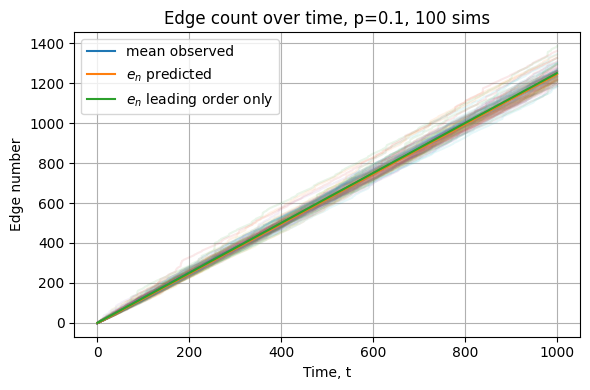

In [12]:
#note that a lot of the "graph plots" have a similar structure, so might not be as well documented as this
#they do similar things as this, except with some of the data renamed i.e. (datatype)Results[p][i]
plt.figure(figsize=(6,4))
p = 0.1
#defines S_inf, the constant prefactor for the p > 1/2 case
S_inf = ((2*p)*(2*p-1)*sp.gamma(2*p))**-1
#plots the edge array for each simulation as a translucent line
for i in range(0, sims):
   plt.plot(edgeResults[p][i], alpha = 0.1)   
#plots mean
plt.plot(edgeMean[p], label =f"mean observed")
upper = np.array(edgeMean[p]) + np.array(edgeStd[p])
lower = np.array(edgeMean[p]) - np.array(edgeStd[p])
#defines our predicted edge number, depends on value of p in accordance with derived solution
x = np.linspace(0, t, t + 1)
if p > 1/2:
    y = x**(2*p) * S_inf
elif p < 1/2:
    y = (x - x**(2*p)) / (1 - 2*p)
else:
    y = x * np.log(x)
y1 = (x) / (1 - 2*p)
plt.plot(x, y, label =f"$e_n$ predicted")
#in these graphs, we plot the leading order term and the two term solutions 
#shows how the importance of the subleading correction increases as p -> 1/2 
plt.plot(x, y1, label =f"$e_n$ leading order only")
#not used here, but seen elsewhere to plot ± 1 std deviation of the mean
#plt.plot(edgeStd[p], label =f"std for p={p}")
#plt.fill_between(x, lower, upper, alpha=0.25, label="±1 std dev")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Edge number")
plt.title(f"Edge count over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

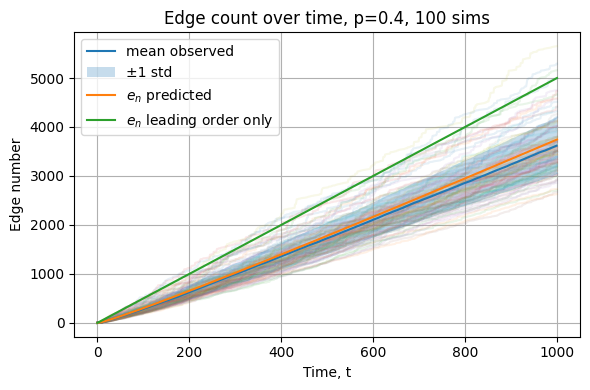

In [13]:
#plots for p = 0.4
plt.figure(figsize=(6,4))
p = 0.4
#defines S_inf, the constant prefactor for the p > 1/2 case
S_inf = ((2*p)*(2*p-1)*sp.gamma(2*p))**-1
for i in range(0, sims):
    plt.plot(edgeResults[p][i], alpha = 0.1)   
#plots mean
plt.plot(edgeMean[p], label =f"mean observed")
x = np.linspace(0, t, t)
upper = np.array(edgeMean[p]) + np.array(edgeStd[p])
lower = np.array(edgeMean[p]) - np.array(edgeStd[p])
#plt.plot(edgeStd[p], label =f"std for p={p}")
plt.fill_between(x, lower, upper, alpha=0.25, label="±1 std")
if p > 1/2:
    y = x**(2*p) * S_inf
elif p < 1/2:
    y = (x - x**(2*p)) / (1 - 2*p)
else:
    y = x * np.log(x)
y1 = (x) / (1 - 2*p)
plt.plot(x, y, label =f"$e_n$ predicted")
plt.plot(x, y1, label =f"$e_n$ leading order only")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Edge number")
plt.title(f"Edge count over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

Looking at the graphs above, we can see that the error in our leading order prediction increases massively as $p \rightarrow 1/2$, making the two term expansion more appropriate in this scheme. Having shown that edge number is linear for $p < 1/2$, we now show the behaviour for $p = 1/2$ and $p > 1/2$.

C:\Users\rapha\AppData\Local\Temp\ipykernel_4584\120589937.py:4: RuntimeWarning: divide by zero encountered in scalar power
  S_inf = ((2*p)*(2*p-1)*sp.gamma(2*p))**-1


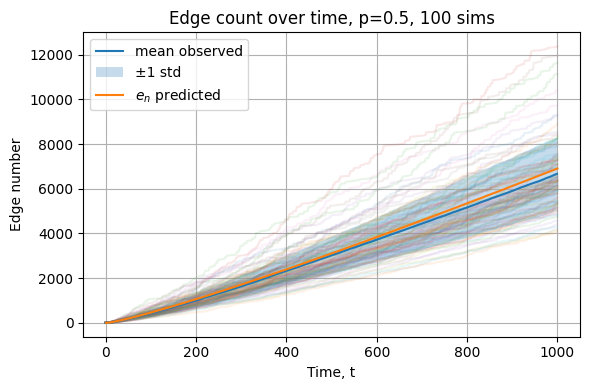

In [14]:
#plot for p = 0.5
plt.figure(figsize=(6,4))
p = 0.5
S_inf = ((2*p)*(2*p-1)*sp.gamma(2*p))**-1
for i in range(0, sims):
    plt.plot(edgeResults[p][i], alpha = 0.1) 
plt.plot(edgeMean[p], label =f"mean observed")
upper = np.array(edgeMean[p]) + np.array(edgeStd[p])
lower = np.array(edgeMean[p]) - np.array(edgeStd[p])
#plt.plot(edgeStd[p], label =f"std for p={p}")
plt.fill_between(x, lower, upper, alpha=0.25, label="±1 std")
x = np.linspace(1, t, t)
if p > 1/2:
    y = x**(2*p) * S_inf
elif p < 1/2:
    y = (x - x**(2*p)) / (1 - 2*p)
else:
    y = x * np.log(x)
plt.plot(x, y, label =f"$e_n$ predicted")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Edge number")
plt.title(f"Edge count over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

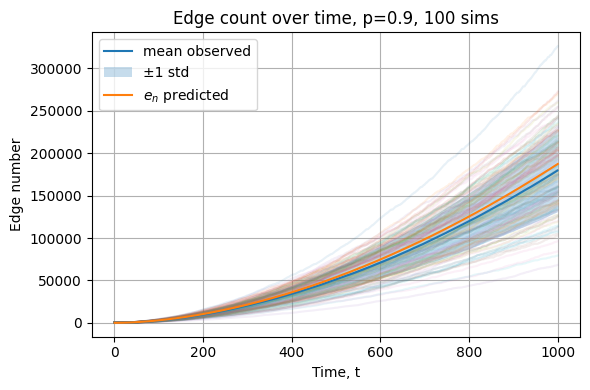

In [15]:
#plot for p = 0.9
plt.figure(figsize=(6,4))
p = 0.9
S_inf = ((2*p)*(2*p-1)*sp.gamma(2*p))**-1
for i in range(0, sims):
    plt.plot(edgeResults[p][i], alpha = 0.1) 
plt.plot(edgeMean[p], label =f"mean observed")
upper = np.array(edgeMean[p]) + np.array(edgeStd[p])
lower = np.array(edgeMean[p]) - np.array(edgeStd[p])
#plt.plot(edgeStd[p], label =f"std for p={p}")
plt.fill_between(x, lower, upper, alpha=0.25, label="±1 std")
x = np.linspace(1, t, t)
if p > 1/2:
    y = x**(2*p) * S_inf
elif p < 1/2:
    y = (x - x**(2*p)) / (1 - 2*p)
else:
    y = x * np.log(x)
plt.plot(x, y, label =f"$e_n$ predicted")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Edge number")
plt.title(f"Edge count over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

We also derived the following behaviour for the mean degree <br>
$
\langle k \rangle =
\begin{cases}
\frac{2}{1-2p} & \text{if } p < 1/2 \\
2\log(n) & \text{if } p = 1/2 \\
2n^{2p-1}S_{\infty}  & \text{if } p > 1/2
\end{cases}
$
<br> but note that edge number is fixed to be double the total degree by the Handshaking Lemma, and hence $\langle k \rangle = \frac{2}{n}e_{n}$ must hold. In the interest of space, none of the mean degree against time graphs were included in the RevTex submission. A graph for the mean degree against $t$ for $p = 0.1$ has been given in this notebook for completeness, and equally because we are not subject to the same space constraints.

In [16]:
#calculates mean/med/std for our variables
pValues = [0.1]
t = 1000
degResults = {}
for p in pValues:
    degResults[p] = {}
    for i in range(0, sims):
        degResults[p][i] = np.zeros(t + 1)
        degResults[p][i][0] = 0
        for n in range(1, t + 1):
            degResults[p][i][n] = 2 * (edgeResults[p][i][n]) / n
degMean = {}
degMed = {}
degStd = {}
for p in pValues:
    degMean[p], degMed[p], degStd[p] = aonMeanStdCalc(degResults[p], t, sims)

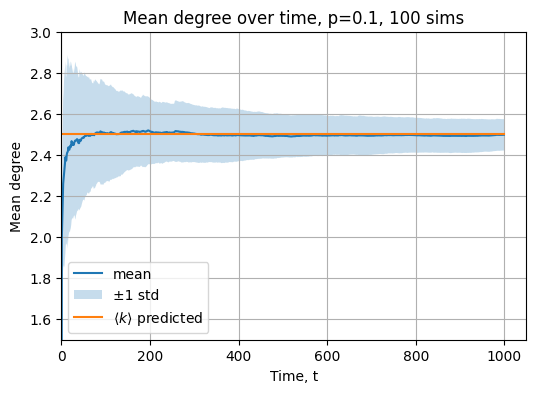

In [17]:
plt.figure(figsize=(6,4))
p = 0.1
for i in range(0, sims):
    plt.plot(degResults[p][i], alpha = 0.0)   
x = np.linspace(0, t, t)
plt.plot(degMean[p], label =f"mean")
upper = np.array(degMean[p]) + np.array(degStd[p])
lower = np.array(degMean[p]) - np.array(degStd[p])
#plt.plot(degStd[p], label =f"std for p={p}")
plt.fill_between(x, lower, upper, alpha=0.25, label='±1 std')
x1 = np.linspace(0, t, 2)
y1 = np.linspace(2 / (1 - 2*p), 2 / (1 - 2*p), 2)
plt.plot(x1, y1, label =f"$⟨k⟩$ predicted")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Mean degree")
plt.title(f"Mean degree over time, p={p}, {sims} sims")
plt.xlim(0)
plt.ylim(1.5, 3)
plt.grid(True)
#plt.tight_layout()
plt.show()

#### Plots for edge number, mean degree against probability
Now, we show plots against probability for fixed times. We expect to show that in the sparse regime, for $p < 1/2$, that edge number grows linearly and mean degree is constant for varying $n$. However, we see that as we approach $p \rightarrow 1/2$, the subleading term becomes more important, so mean degree is larger for larger $n$ (near $p = 1/2$). 

Looking at the behaviour of edge number and fixed degree for varying $p$, we do clearly see piecewise behaviour. For $p < 1/2$, mean degree grows as the constant $2 / (1-2p)$ grows, and then grows exponentially for varying $p$ in the dense regime of $p > 1/2$.

In [18]:
#plots edge number against p for varying values of n, meant to show how edge number grows for different p
#uses saved graphs (generated above), and finds edge number for their subgraphs
#since nodes are labelled as they are added, we take the first n nodes and find edge number for those
#so we can see how edge number

#initialisation for pValues and tValues we are testing over
pValues = [i * 0.02 for i in range(0, 46)]
t = 1000
tValues = [30, 100, 300, 1000]
sims = 100
edgeFullResults = {}
edgeResults = {}

#for naming conventions of saved graphs
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

for t in tValues:
    subNodes = [i for i in range(1, t + 1)] #defines the first n nodes for a subgraph
    #initialises each dictionary entry at time t as a dictionary for pValues
    edgeFullResults[t] = {}
    edgeResults[t] = {}
    for p in pValues:
        #for naming conventions
        pstr = str(p)[2:]
        edgeArray = []
        for i in range(1, sims + 1):
            #opens saved g
            with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
                G = pickle.load(f)
            Gsub = G.subgraph(subNodes) #gives subgraph, effectively showing G at an earlier time
            edgeArray.append(nx.number_of_edges(Gsub)) #calculates edge number for given t, p
        #saves results (and mean) for given t, p 
        edgeFullResults[t][p] = edgeArray
        edgeResults[t][p] = np.nanmean(edgeArray)

In [19]:
#note that our array doesn't find the edge number for p = 1, clearly this is a complete graph
#this wasn't initially generated to save space on my laptop
#so we will have to manually add these entries in
p = 1.0
for t in tValues:
    edgeArray = []
    Gsub = nx.complete_graph(t+1)
    edgeCount = nx.number_of_edges(Gsub)
    for i in range(1, sims + 1):
        edgeArray.append(edgeCount)
    edgeFullResults[t][p] = edgeArray
    edgeResults[t][p] = np.nanmean(edgeArray)

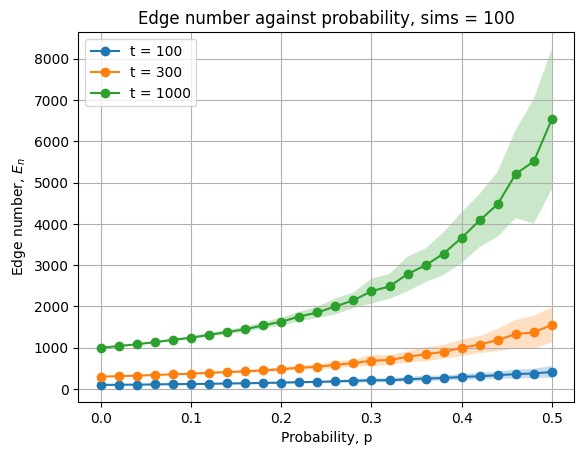

In [20]:
#edge number for p < 1/2, sparse regime, E_n grows linearly
#close to p = 1/2, the constant tends to infinity so it diverges from the linear growth
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 26)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = edgeFullResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Edge number, $E_n$")
plt.title(f"Edge number against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

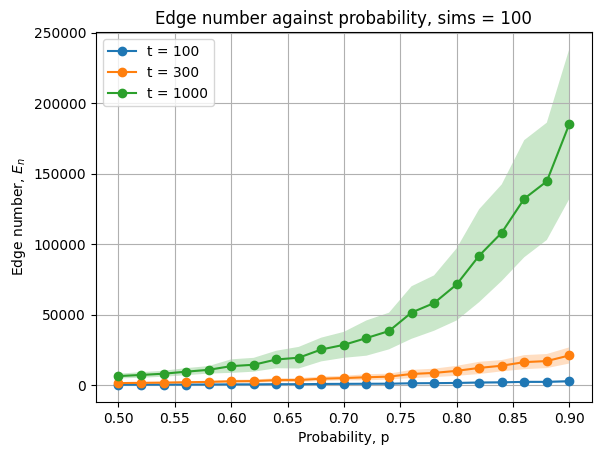

In [21]:
#edge number for p > 1/2, dense regime, E_n grows superlinearly
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(25, 46)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = edgeFullResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Edge number, $E_n$")
plt.title(f"Edge number against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
#mean degree calculation
pValues = [i * 0.02 for i in range(0, 46)]
tValues = [30, 100, 300, 1000]
degResults = {}
for t in tValues:
    degResults[t] = {}
    for p in pValues:
        degResults[t][p] = np.zeros(sims) 
        for i in range(0, sims):
            degResults[t][p][i] = 2 * edgeFullResults[t][p][i] / (t + 1)
#degMean = {}
#degMed = {}
#degStd = {}
#for p in pValues:
#    degMean[p], degMed[p], degStd[p] = aonMeanStdCalc(degResults[p], t, sims)

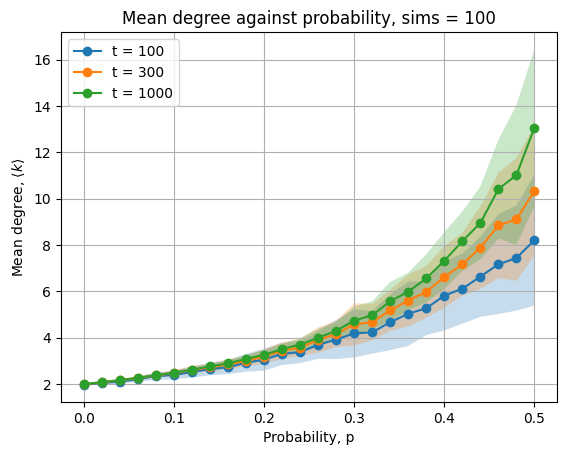

In [24]:
#mean degree for p < 1/2, stationary
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 26)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = degResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Mean degree, $⟨k⟩$")
plt.title(f"Mean degree against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

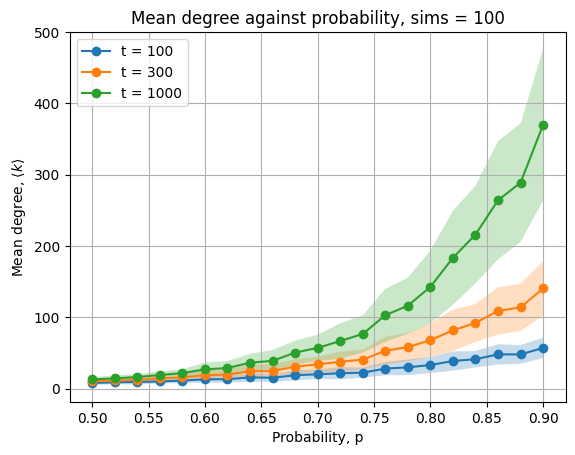

In [25]:
#mean degree for p > 1/2, non-stationary
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(25, 46)]
tValues = [100, 300, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = degResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Mean degree, $⟨k⟩$")
plt.title(f"Mean degree against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

## Standard Deviation
We also derived the following behaviour for the variance and standard deviation. <br>
$
\sigma_{E_{n}}^2 \sim
\begin{cases}
n & \text{if } p < 1/4 \\
n\log(n) & \text{if } p = 1/4 \\
n^{4p} & \text{if } p > 1/4
\end{cases}
\ \ \
\text{and} 
\ \ \
\sigma_{E_{n}} \sim
\begin{cases}
\sqrt{n} & \text{if } p < 1/4 \\
\sqrt{n\log(n)} & \text{if } p = 1/4 \\
n^{2p} & \text{if } p > 1/4
\end{cases}
$
<br> Note that the threshold for switching occurs at $p = 1/4$, so we'll be looking at the standard deviation of the edge number for two p values either side of this threshold.

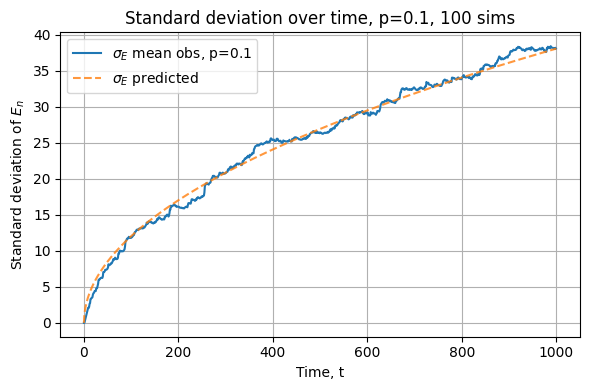

In [26]:
plt.figure(figsize=(6,4))
p = 0.1
S_inf = ((2*p)*(2*p-1)*sp.gamma(2*p))**-1
plt.plot(edgeStd[p], label =f"$\sigma_E$ mean obs, p={p}")
#for i in range(0, sims):
#    plt.plot(edgeResults[p][i], alpha = 0.1)   
x = np.linspace(0, t, t)
if p > 1/4:
    y = x ** (2*p)
elif p < 1/4:
    y = np.sqrt(x) 
else:
    y = np.sqrt(x * np.log(x))
y = (edgeStd[p][-1]/y[-1])*y #rescales standard deviation based on experimental data
plt.plot(x, y, label =f"$\sigma_E$ predicted", linestyle = "--", alpha = 0.8)
#plt.plot(edgeMean[p], label =f"mean for p={p}")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Standard deviation of $E_n$")
plt.title(f"Standard deviation over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

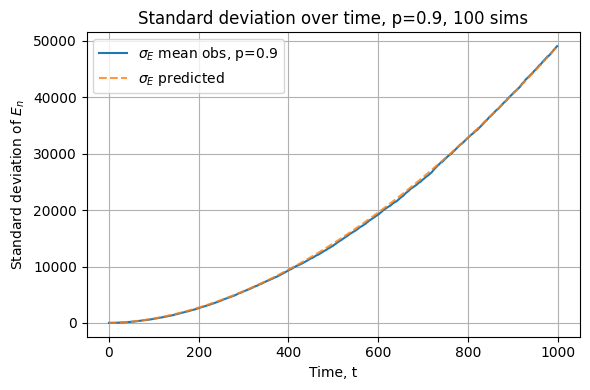

In [27]:
plt.figure(figsize=(6,4))
p = 0.9
S_inf = ((2*p)*(2*p-1)*sp.gamma(2*p))**-1
plt.plot(edgeStd[p], label =f"$\sigma_E$ mean obs, p={p}")
#for i in range(0, sims):
#    plt.plot(edgeResults[p][i], alpha = 0.1)   
x = np.linspace(0, t, t)
if p > 1/4:
    y = x ** (2*p)
elif p < 1/4:
    y = np.sqrt(x) 
else:
    y = np.sqrt(x * np.log(x))
y = (edgeStd[p][-1]/y[-1])*y #rescales standard deviation based on experimental data
plt.plot(x, y, label =f"$\sigma_E$ predicted", linestyle = "--", alpha = 0.8)
#plt.plot(edgeMean[p], label =f"mean for p={p}")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Standard deviation of $E_n$")
plt.title(f"Standard deviation over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

## Expected Triangle Number
Defining $t_{n} = \mathbb{E}[T_{n}]$ as the expected triangle number, we derived the recurrence relation

$t_{n+1} = (1 + \frac{3p}{n}) t_{n} + \frac{2p}{n} e_{n}$

with leading order solution given by

$t_n \sim
\begin{cases}
n & \text{if } p < 1/3 \\
n\log(n) & \text{if } p = 1/3 \\
n^{3p} & \text{if } p > 1/3\\ 
\end{cases}$

The threshold for switching now sits at $p = 1/3$, so we'll look at how the behaviour changes between on either side of this threshold.  

Also, note that from this point forward, we're going to plot our predicted expected values based on manually evaluating the recurrence relation. These calculations are fairly fast in Python (for $n \approx 100000$, which is the maximum value of n that we are working with here), and are more accurate for small n where the subleading terms. <br> 
For each characteristic below, we plot our derived leading order behaviour against the corresponding recurrence relation for $n = 100000$ to show asymptotically that we have derived the correct leading order behaviour. <br>
We will fix the prefactor by substituting the values at $n = 100000$. 
(i.e. for $t_n \sim n^{3p}$, we know that $t_n = Cn^{3p}$ for some constant $C$. We will fix $C$ by running our recurrence relation to some large $n$ ($n = 100000$ in this case), and then use this value to fix the prefactor)

In [28]:
#leading order behaviour against recurrence relation predictions for p = 0.3, p = 0.4

In [29]:
#function to find expected number of triangles recursively, also returns edge number
def tnArr(n_max, p):
    e = np.zeros(n_max + 1)
    t = np.zeros(n_max + 1)

    #initial conditions for the recurrence relation
    e[1] = 0
    e[2] = 1
    t[1] = 0
    t[2] = 0

    #recurrence relation as derived in the RevTex submission
    for n in range(2, n_max):
        e[n+1] = (1 + 2*p/n) * e[n] + 1
        t[n+1] = (1 + 3*p/n) * t[n] + (2*p/n) * e[n]

    return e, t

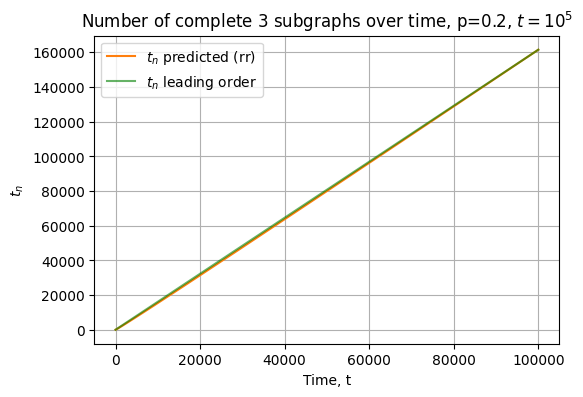

In [30]:
#plots the recurrence relation solution against the derived leading order behaviour
n_max = 10**5 + 1
p = 0.2
en, tn = tnArr(n_max, p)
plt.figure(figsize=(6,4))
plt.plot(tn, label =f"$t_n$ predicted (rr)", color = "tab:orange")
#gives leading order behaviour as derived
x = np.linspace(0, n_max, n_max)
if p > 1/3:
    y = x**(3*p)
elif p == 1/3:
    y = x*np.log(x) 
else:
    y = x
#we determine the prefactor by normalising against the recurrence relation solution for large n
y = (tn[-1]/y[-1])*y
plt.plot(x, y, label=f"$t_n$ leading order", color = "g", alpha = 0.6)
plt.legend()
plt.xlabel("Time, t")
plt.ylabel(f"$t_n$")
plt.title(f"Number of complete 3 subgraphs over time, p={p}, $t = 10^5$")
plt.grid(True)
#plt.tight_layout()
plt.show()

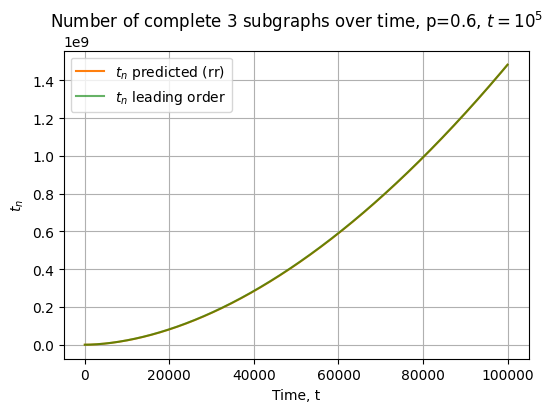

In [31]:
#plots the recurrence relation solution against the derived leading order behaviour
#this plots for p = 0.4, showing how the behaviour becomes exponential
n_max = 10**5 + 1
p = 0.6
en, tn = tnArr(n_max, p)
plt.figure(figsize=(6,4))
plt.plot(tn, label =f"$t_n$ predicted (rr)", color = "tab:orange")
#gives leading order behaviour as derived
x = np.linspace(0, n_max, n_max)
if p > 1/3:
    y = x**(3*p)
elif p == 1/3:
    y = x*np.log(x) 
else:
    y = x
#we determine the prefactor by normalising against the recurrence relation solution for large n
y = (tn[-1]/y[-1])*y
plt.plot(x, y, label=f"$t_n$ leading order", color = "g", alpha = 0.6)
plt.legend()
plt.xlabel("Time, t")
plt.ylabel(f"$t_n$")
plt.title(f"Number of complete 3 subgraphs over time, p={p}, $t = 10^5$")
plt.grid(True)
#plt.tight_layout()
plt.show()

This verifies that our asymptotics for the triangle number agree with the direct recurrence relation computation, with $p = 0.2$ giving linear behaviour and $p = 0.6$ giving superlinear behaviour. Now we can check our recurrence relation against the observed triangle number.

In [32]:
#function to determine mean triangle number for a fixed p
#takes a [samples] number of samples to improve efficiency, and averages over [sims] sims
def aonTriFixP(G, p, samples, sampleTime, sims):
    results = {}
    for k in range(0, sims):
        Gcopy = G.copy()
        randArray = rng.binomial(1, p, size=(samples, sampleTime)) 
        #determines rng before, with [samples] arrays of length [sampleTime]
        triArray = [0]
        for i in range(0, samples):
            triInSample = 0
            for j in range(0, sampleTime):
                n = Gcopy.number_of_nodes()
                t = np.random.choice(Gcopy.nodes()) #chooses target
                Gcopy.add_node(n + 1)
                node = (i * sampleTime) + (j + 1) + 1 #for testing
                if randArray[i][j] == 1: #i.e. if copying occurs
                    neighbours = list(Gcopy.neighbors(t))
                    for nb in neighbours:
                        Gcopy.add_edge(n + 1, nb) #adds edges to target's neighbours
                    Gcopy.add_edge(n + 1,t) #adds edge to target
                    #this means we can improve efficiency by, at each timestep, only counting triangles incident to the new node
                    triInSample += nx.triangles(Gcopy, node) #sums no. of triangles found in this sample
                else:
                    Gcopy.add_edge(n + 1,t)
            triArray.append(triInSample + triArray[i]) #cumulative triangle number
        results[k] = triArray
    return results

In [33]:
#triangle number against predicted triangle number for p = 0.2, p = 0.4
#generating triangle number results for p values below, with 50 samples every 20 timesteps
samples = 50
sampleTime = 20
pValues = [0.2, 0.6]
sims = 100
triResults = {}
for p in pValues:
    triResults[p] = aonTriFixP(G_init, p, samples, sampleTime, sims)

In [34]:
#calculates mean/med/std for our variables
triMean = {}
triMed = {}
triStd = {}
for p in pValues:
    triMean[p], triMed[p], triStd[p] = aonMeanStdCalc(triResults[p], samples + 1, sims)
    #we have (samples + 1) because the mean value calculation includes the "zero" sample in position [0]

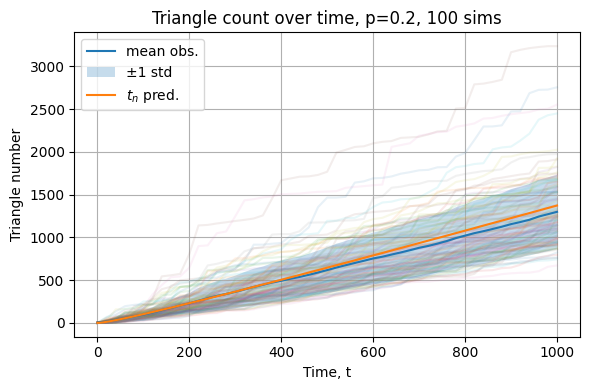

In [35]:
#plots triangle count against time, similar to the edge count plot (see documentation in edge count plot)
#p = 0.2 so we have linear growth in t_n
plt.figure(figsize=(6,4))
p = 0.2
n_max = samples * sampleTime
x = np.linspace(0, n_max, samples + 1)
for i in range(0, sims):
    plt.plot(x, triResults[p][i], alpha = 0.1)  
plt.plot(x, triMean[p], label ="mean obs.")
upper = np.array(triMean[p]) + np.array(triStd[p])
lower = np.array(triMean[p]) - np.array(triStd[p])
#plt.plot(triStd[p], label =f"std for p={p}")
plt.fill_between(x, lower, upper, alpha=0.25, label="±1 std")
en, tn = tnArr((n_max), p)
x1 = np.linspace(0, n_max, n_max + 1)
plt.plot(x1, tn, label =f"$t_n$ pred.")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Triangle number")
plt.title(f"Triangle count over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

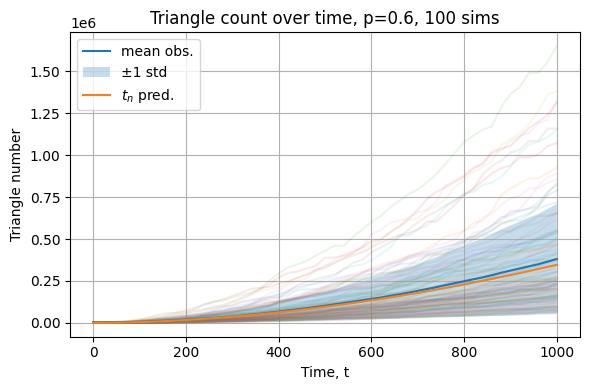

In [36]:
#plots triangle count against time, similar to the edge count plot (see documentation in edge count plot)
#again, note that p = 0.6, so we have superlinear growth in t_n
plt.figure(figsize=(6,4))
p = 0.6
n_max = samples * sampleTime
x = np.linspace(0, n_max, samples + 1)
for i in range(0, sims):
    plt.plot(x, triResults[p][i], alpha = 0.1)  
plt.plot(x, triMean[p], label ="mean obs.")
upper = np.array(triMean[p]) + np.array(triStd[p])
lower = np.array(triMean[p]) - np.array(triStd[p])
#plt.plot(triStd[p], label =f"std for p={p}")
plt.fill_between(x, lower, upper, alpha=0.25, label="±1 std")
en, tn = tnArr((n_max), p)
x1 = np.linspace(0, n_max, n_max + 1)
plt.plot(x1, tn, label =f"$t_n$ pred.")
plt.legend()
plt.xlabel("Time, t")
plt.ylabel("Triangle number")
plt.title(f"Triangle count over time, p={p}, {sims} sims")
plt.grid(True)
plt.tight_layout()
plt.show()

## Clustering Coefficient
In the final RevTex submission, we calculated the clustering coefficient defined as
$C_n = \frac{3 \times \text{number of triangles}}{\text{number of triplets}}$,
where we define connected triplets as groups of three vertices connected by two edges (i.e. two vertices are adjacent to the third). <br>
We found a recurrence for the triangle number (above) and for the triplet number, $\tau_{n+1} = (1+\frac{3p}{n})\tau_n + \frac{2+4p}{n}e_n$, which had the same leading order behaviour as the triangle number. We found that for large n, $C_n$ would depend on the ratio of their forcing terms, more concretely that <br>
$C_n = \frac{3 \times 2p}{2 + 4p} = \frac{3p}{1 + 2p}$ <br>
i.e. we have that $C_n \rightarrow C_\infty (p)$ with $C_\infty (p) = \frac{3p}{1 + 2p}$. In the graph below, we see that this convergence does happen, with the clustering coefficient approaching the asymptotic limit from below. We also note that the standard deviation converges for all p, albeit much more slowly for $p > 1/2$ in the dense case.

In [37]:
#plots clustering coefficient against p for varying values of n, meant to show how C_n converges
#uses saved graphs (generated above), and finds clustering coefficient for their subgraphs
#since nodes are labelled as they are added, we take the first n nodes and find C_n for those
#so we can see how clustering converges over time

#initialisation for pValues and tValues we are testing over
pValues = [i * 0.02 for i in range(0, 41)]
t = 1000
tValues = [30, 100, 300, 1000]
sims = 10
clustFullResults = {}
clustResults = {}

#for naming conventions of saved graphs
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

for t in tValues:
    subNodes = [i for i in range(1, t + 1)] #defines the first n nodes for a subgraph
    #initialises each dictionary entry at time t as a dictionary for pValues
    clustFullResults[t] = {}
    clustResults[t] = {}
    for p in pValues:
        #for naming conventions
        pstr = str(p)[2:]
        clustArray = []
        for i in range(1, sims + 1):
            #opens saved g
            with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
                G = pickle.load(f)
            Gsub = G.subgraph(subNodes) #gives subgraph, effectively showing G at an earlier time
            clustArray.append(nx.transitivity(Gsub)) #calculates clustering for given t, p
            #note that the command for our definition is the "nx.transitivity(G)" command, as opposed to clustering_coefficient
            #which refers to other definition of clustering coefficient
        #saves results (and mean) for given t, p 
        clustFullResults[t][p] = clustArray
        clustResults[t][p] = np.nanmean(clustArray)

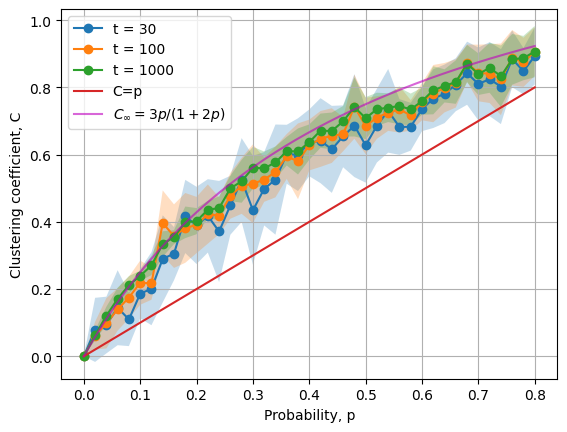

In [38]:
#this cell is used to find the mean/std/med for our stationary graphs (data against varying p)
#similar setup for the assortativity graph
#defines dictionaries for mean/std/med
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 41)]
tValues = [30, 100, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = clustFullResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.plot(np.linspace(0, 0.8, 2), np.linspace(0, 0.8, 2), label="C=p")
x = np.linspace(0, 0.8, 1000)
y = 3*x/(1+2*x)
plt.plot(x, y, label="$C_{\infty}=3p/(1+2p)$", color = "m", alpha = 0.6)
plt.xlabel("Probability, p")
plt.ylabel("Clustering coefficient, C")
#plt.title(f"Clustering coefficient against probability, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

In a previous version of the mini-project, we calculated the global clustering coefficient instead, defined as <br> 
$C_n = \frac{1}{n}\sum_{i = 1}^{n} C_i^L$ with $C_i^L = \frac{\text{no of triangles at the ith node}}{k_{i}(k_i - 1)/2}$, <br>
We did not have a closed analytical form. However, we have a recurrence relation <br>
$\mathbb{E}[C_{n+1}] = \frac{n\mathbb{E}[C_{n}] + \mathbb{E}[C_{n+1}^L]}{n+1}$ with $\mathbb{E}[C_{n+1}^L] = np \frac{3t_n + 2e_n}{e_{n}(2e_{n}+n)}$
<br> and initial conditions given by the fact that we cannot have any triangles before $n = 3$, i.e. $C_{1}, C_{2} = 0$.
While it was possible to compute this clustering coefficient, it was impractical to find a closed analytical form. 

It was trivial, however, to find the more important result that the $C_{n} \rightarrow C_\infty(p)$ with a bound $C_\infty(p) > p$. This is supported by experimental evidence in the graph below. As the number of nodes increases, we see not only that the clustering coefficient converges, but its standard deviation also falls.

In [39]:
#plots clustering coefficient against p for varying values of n, meant to show how C_n converges
#uses saved graphs (generated above), and finds clustering coefficient for their subgraphs
#since nodes are labelled as they are added, we take the first n nodes and find C_n for those
#so we can see how clustering converges over time

#initialisation for pValues and tValues we are testing over
pValues = [i * 0.02 for i in range(0, 41)]
t = 1000
tValues = [30, 100, 300, 1000]
sims = 10
clustFullResults = {}
clustResults = {}

#for naming conventions of saved graphs
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

for t in tValues:
    subNodes = [i for i in range(1, t + 1)] #defines the first n nodes for a subgraph
    #initialises each dictionary entry at time t as a dictionary for pValues
    clustFullResults[t] = {}
    clustResults[t] = {}
    for p in pValues:
        #for naming conventions
        pstr = str(p)[2:]
        clustArray = []
        for i in range(1, sims + 1):
            #opens saved g
            with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
                G = pickle.load(f)
            Gsub = G.subgraph(subNodes) #gives subgraph, effectively showing G at an earlier time
            clustArray.append(nx.average_clustering(Gsub)) #calculates clustering for given t, p
        #saves results (and mean) for given t, p 
        clustFullResults[t][p] = clustArray
        clustResults[t][p] = np.nanmean(clustArray)

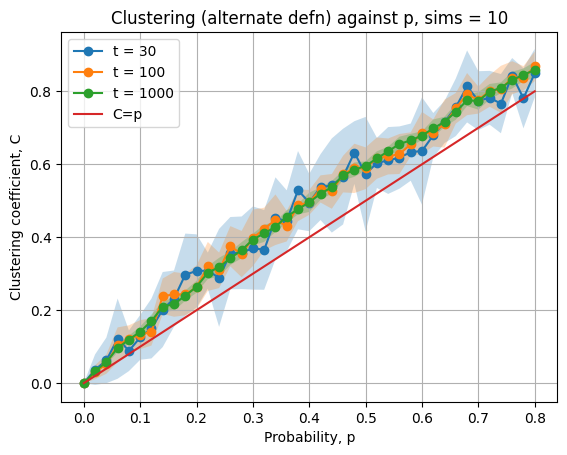

In [40]:
#this cell is used to find the mean/std/med for our stationary graphs (data against varying p)
#similar setup for the assortativity graph
#defines dictionaries for mean/std/med
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 41)]
tValues = [30, 100, 1000]
#simply makes a list that fixes t, and finds the mean/std/med for each p
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = clustFullResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])

    #we also calculate 1 std away from the mean so we can graph it
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.plot(np.linspace(0, 0.8, 2), np.linspace(0, 0.8, 2), label="C=p")
plt.xlabel("Probability, p")
plt.ylabel("Clustering coefficient, C")
plt.title(f"Clustering (alternate defn) against p, sims = {sims}")
plt.grid(True)
plt.legend()
plt.show()

## Degree Distribution
#### Sparse Regime
Similarly to the clustering coefficient, we found that the degree distribution becomes stationary for large n, following the recurrence relation
$f_{k} = \frac{1-p}{2+p} \prod_{j=2}^{k}\frac{1+pj}{2+pj}$
This has the solution $f_{k} = \gamma_{p}k^{-\frac{1}{p}}$ with $\gamma_{p} = \frac{(1-p) \ \Gamma(2+2/p)}{(2+p) \ \Gamma(2+1/p)}$. <br>
However, note that the effect of copying (which causes the stationary assumption to break down for $p > 1/2$) can also cause our solution to be an underestimate for large enough values of p that are still in the sparse regime. Note that the power law holds for $p = 0.02$ and for $p = 0.2$, but our solution noticeably underestimates the number of nodes of degree k for $p = 0.2$. Summing the number of predicted nodes confirms this to be the case.

In [41]:
#Degree distributions for p = 0.02, p = 0.2.

In [42]:
#cell to find the degree distribution, similar to the code for the clustering
#uses data from saved graphs but only for fixed p here
p = 0.02
pValues = [p]
degHistFullResults = {}
degHistResults = []
sims = 100
t = 1000
for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    edgeArray = []
    for i in range(1, sims + 1):
        with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
            G = pickle.load(f)
        #gets degree histogram from G
        degHist = np.array(nx.degree_histogram(G))
        #degree_histogram(G) gives arrays of varying length, for mean/std calculations we want the same length
        #so we use the pad command to fix the length
        l_diff = t - len(degHist)
        degHistPad = np.pad(degHist, (0, l_diff))
        degHistFullResults[i-1] = degHistPad

In [43]:
#finds mean/std for deg histogram
degHistMean, degHistMed, degHistStd = aonMeanStdCalc(degHistFullResults, t, sims)

In [44]:
#functions to generate the expected degree distribution from the recurrence relation
#fkArr gives the fraction, fkArrUn gives the unnormalised version (multiplied by n)
def fkArr(k_max, p):
    f = np.zeros(k_max + 1)
    k = np.zeros(k_max + 1)

    f[1] = (1 - p) / (2 + p)
    for j in range(1, k_max):
        f[j+1] = ((1 + p*j) / (2 + p*j)) * f[j]

    return f

def fkArrUn(k_max, p, n):
    f = np.zeros(k_max + 1)
    k = np.zeros(k_max + 1)

    f[1] = n * (1 - p) / (2 + p)
    for j in range(1, k_max):
        f[j+1] = ((1 + p*j) / (2 + p*j)) * f[j]

    return f

Total area of predicted degree distribution: 991.089108910891


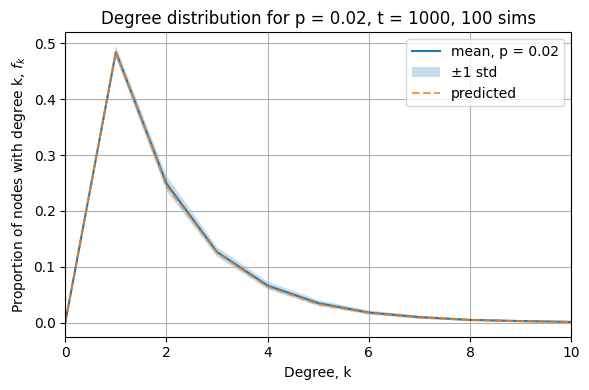

In [45]:
#code to plot the degree distribution, similar to the edge number plot
p = 0.02
plt.figure(figsize=(6,4))
#we print out the "total area" of the predicted distribution, this is meant to quantify how much
#of an underestimate our degree distribution prediction is
#the graph is on 1000 nodes, so the difference is down to our derived stationary distribution
#not taking into account the large cliques created by the copying process
f_k = (fkArrUn(t, p, t + 1))
print("Total area of predicted degree distribution:", np.sum(f_k))
#for i in range(0, sims):
#    plt.plot(degHistFullResults[i], alpha = 0.05)  
plt.plot(np.array(degHistMean) / t, label =f"mean, p = {p}")
upper = (np.array(degHistMean) + np.array(degHistStd)) / t
lower = (np.array(degHistMean) - np.array(degHistStd)) / t
plt.fill_between(np.linspace(0, 1000, 1000), lower, upper, alpha=0.25, label='±1 std')
plt.plot(f_k / t, label="predicted", linestyle = "--", alpha = 0.8)
#we normalise the degree distributions by dividing by t
plt.legend()
plt.xlabel("Degree, k")
plt.ylabel("Proportion of nodes with degree k, $f_k$")
plt.title(f"Degree distribution for p = {p}, t = {t}, {sims} sims")
plt.grid(True)
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

In [46]:
#identical to code for previous graph but with p = 0.2
p = 0.2
pValues = [p]
degHistFullResults = {}
degHistResults = []
sims = 100
t = 1000
for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    edgeArray = []
    for i in range(1, sims + 1):
        with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
            G = pickle.load(f)
        degHist = np.array(nx.degree_histogram(G))
        l_diff = t - len(degHist)
        degHistPad = np.pad(degHist, (0, l_diff))
        degHistFullResults[i-1] = degHistPad

In [47]:
degHistMean, degHistMed, degHistStd = aonMeanStdCalc(degHistFullResults, t, sims)

Total area of predicted degree distribution: 909.9999973291834


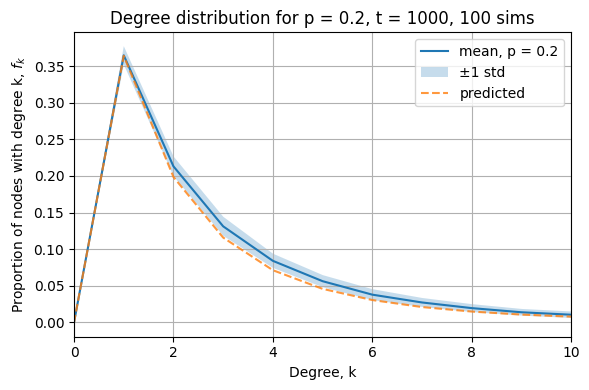

In [48]:
p = 0.2
plt.figure(figsize=(6,4))
#note that the total area is significantly lower than 1000
#copying is more common, so we see more cliques that are not predicted by our stationary distribution
f_k = (fkArrUn(t, p, t + 1))
print("Total area of predicted degree distribution:", np.sum(f_k))
#for i in range(0, sims):
#    plt.plot(degHistFullResults[i], alpha = 0.05)  
plt.plot(np.array(degHistMean) / t, label =f"mean, p = {p}")
upper = (np.array(degHistMean) + np.array(degHistStd)) / t
lower = (np.array(degHistMean) - np.array(degHistStd)) / t
plt.fill_between(np.linspace(0, 1000, 1000), lower, upper, alpha=0.25, label='±1 std')
plt.plot(f_k / t, label="predicted", linestyle = "--", alpha = 0.8)
#we normalise the degree distributions by dividing by t
plt.legend()
plt.xlabel("Degree, k")
plt.ylabel("Proportion of nodes with degree k, $f_k$")
plt.title(f"Degree distribution for p = {p}, t = {t}, {sims} sims")
plt.grid(True)
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

#### Dense Regime and how the Clique Number can help our prediction
Somewhat surprisingly, our solution actually replicates the degree distribution very well (in the dense regime, $p > 1/2$) for low values of k. However the additional nodes of high degree which form in cliques due to copying are not predicted at all. This can be somewhat remedied by our clique number predictions.

Clique number describes the size of the largest complete subgraph in $G_{n}$. The RevTex paper describes two methods to find the clique number. The simpler estimate tracks the growth of the original $K_2 = G_2$ clique. We define this clique number as $c_n$ and find the recurrence relation $c_{n+1} = (1 + \frac{p}{n})c_{n}$, with solution $c_n \sim n^p$. 

Defining $K_m(n)$ to be the expected number of cliques of size m to be found in a graph $G_{n}$, we find that clique number follows the recurrence relation <br>
$K_{m+1} (n+1) = (1+\frac {p(m+1)}{n})K_{m+1} (n) + \frac {pm}{n}K_{m} (n)$ with the initial condition that $K_m(n) = 0$ for $m < n$.
<br> Solving recursively gives the solution <br>
$
K_{m} (n) \sim
\begin{cases}
n & \text{if } p < 1/m \\
n\log(n) & \text{if } p = 1/m \\
n^{mp}  & \text{if } p > 1/m
\end{cases}
$

In [49]:
#calculates clique number across varying n (fixed p), but we use the saved graph data again
#uses the subgraph trick as before, taking samples of clique number at regular intervals 
pValues = [0.8]
t = 1000
sims = 100
cliqFullResults = {}
cliqResults = {}
cliqMedResults = {}

samples = 20
sampleTime = 50

for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    cliqArray = []
    for i in range(0, sims):
        with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i+1}.pkl", "rb") as f:
            G = pickle.load(f)
        Gsub = G.subgraph(1)
        subNodes = [1]
        cliqArray = [0]
        for j in range(0, samples):
            #adds the next sampleTime nodes to the subgraph
            for k in range(j * sampleTime + 2, (j + 1) * sampleTime + 2):
                subNodes.append(k)
            Gsub = G.subgraph(subNodes) #defines subgraph
            cliqArray.append(max(len(c) for c in nx.find_cliques(Gsub))) #finds max clique
        cliqFullResults[i] = cliqArray
    cliqMeanArr, cliqMedArr, cliqStdArr = aonMeanStdCalc(cliqFullResults, samples + 1, sims)
    cliqResults[p] = cliqMeanArr
    cliqMedResults[p] = cliqMedArr

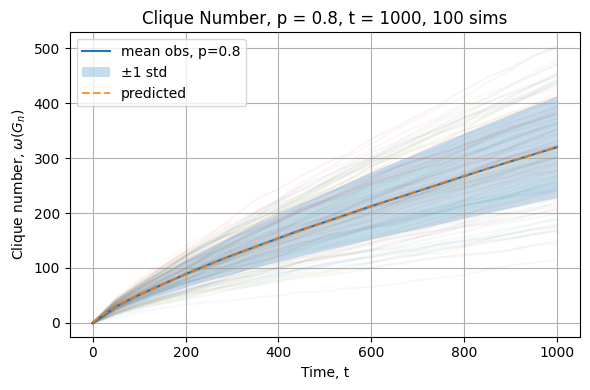

In [50]:
#plots clique number against varying t
plt.figure(figsize=(6,4))
pValues = [0.8]
#plots the clique number against t for each simulation
for i in range(0, sims):
    plt.plot([i * sampleTime for i in range(0, samples + 1)], cliqFullResults[i], alpha = 0.05)  
#plots the mean
for p in pValues:
    plt.plot([i * sampleTime for i in range(0, samples + 1)], cliqResults[p], label=f"mean obs, p={p}")  
upper = np.array(cliqMeanArr) + np.array(cliqStdArr)
lower = np.array(cliqMeanArr) - np.array(cliqStdArr)
plt.fill_between(np.linspace(0, 1000, samples + 1), lower, upper, alpha=0.25, label='±1 std')
#plots the prediction, note that this is normalised using the mean at t = 1000
x = np.linspace(0, sampleTime * samples, sampleTime * samples)
y = x**p
y = cliqResults[p][-1]/y[-1] * y
plt.plot(x, y, label=f"predicted", alpha = 0.8, linestyle = "--")
plt.xlabel("Time, t")
plt.ylabel("Clique number, $\omega(G_n)$")
plt.title(f"Clique Number, p = {p}, t = {t}, {sims} sims")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<br> If we want to predict the clique number, it is easier to simulate for large n, fixing the constant prefactors for each $K_m(n)$ using experimental data. We cannot simply fix $K_m(n) \geq 1$ and then define the clique number as $\omega_n := $ {$ max(m): K_{m} \subseteq G_{n}$}, to find what we'd expect to be the largest clique. This method will lead to a (likely huge) overestimate, as the mean clique number is heavily skewed by outliers. <br> <br>
However, these large n simulations are very slow on dense graphs (and would often end up slower than simply completing the clique number directly), so it is more practical to use our simple estimate for clique size for $p = 0.8$, fixing the prefactor using experimental data. The simple estimate predicts the clique number very well, as above.

This calculation can be used to predict the spike in degree distribution. Plotting the degree distribution for $p = 0.8$, we can see that while our prediction only a small underestimate for nodes of low degree, the spikes of nodes at high degree are not predicted by our stationary distribution. However, looking at the clique number suggests the existence of $\omega_n$ nodes of degree $\omega_n$, which goes some way to predicting the existence of the spikes of high degree that would otherwise not be predicted.

In [51]:
print(y[-1])

319.89


Our simulation predicts a spike of many nodes at degree $k \approx 320$, which agrees with the experimental data below. We expect the height of the spike to be less than $\omega(G_n)$ because many nodes in the clique may have external neighbours that increase their degree slightly. <br> <br>
Note that not all of the plots below were used in the RevTex submission (due to issues with space), but will be submitted here for completeness (and also to illustrate the peak/long tail more clearly).

In [52]:
#degree distribution for p = 0.8
p = 0.8
pValues = [p]
degHistFullResults = {}
degHistResults = []
sims = 100
t = 1000
for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    edgeArray = []
    for i in range(1, sims + 1):
        with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
            G = pickle.load(f)
        degHist = np.array(nx.degree_histogram(G))
        l_diff = t - len(degHist)
        degHistPad = np.pad(degHist, (0, l_diff))
        degHistFullResults[i-1] = degHistPad

In [53]:
degHistMean, degHistMed, degHistStd = aonMeanStdCalc(degHistFullResults, t, sims)

Total area of predicted degree distribution: 565.8896616538683


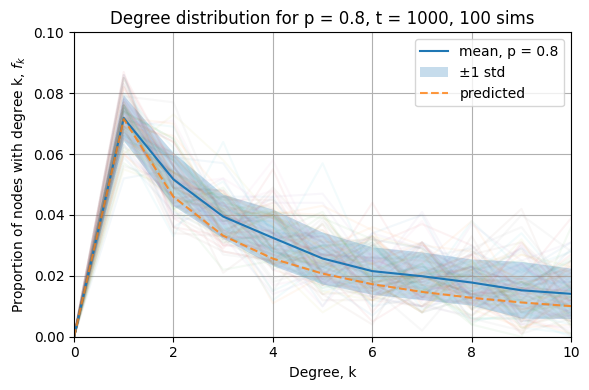

In [54]:
#plot shows the low degree peak (up to k = 10)
p = 0.8
plt.figure(figsize=(6,4))
n = t + 1
f_k = (fkArrUn(t, p, t + 1))
print("Total area of predicted degree distribution:", np.sum(f_k))
for i in range(0, sims):
    plt.plot(np.array(degHistFullResults[i]) / t, alpha = 0.05)  
plt.plot(np.array(degHistMean) / t, label =f"mean, p = {p}")
upper = (np.array(degHistMean) + np.array(degHistStd)) / t
lower = (np.array(degHistMean) - np.array(degHistStd)) / t
plt.fill_between(np.linspace(0, 1000, 1000), lower, upper, alpha=0.25, label='±1 std')
plt.plot(f_k / t, label="predicted", linestyle = "--", alpha = 0.8)
#we normalise the degree distributions by dividing by t
plt.legend()
plt.xlabel("Degree, k")
plt.ylabel("Proportion of nodes with degree k, $f_k$")
plt.title(f"Degree distribution for p = {p}, t = {t}, {sims} sims")
plt.grid(True)
plt.xlim(0, 10)
plt.ylim(0, 0.1)
plt.tight_layout()
plt.show()

Total area of predicted degree distribution: 565.8896616538683


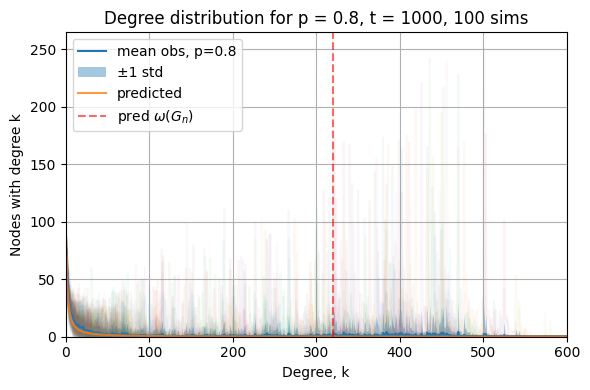

In [55]:
#plot shows the whole distribution (k = 0 to k = 600)
p = 0.8
plt.figure(figsize=(6,4))
f_k = (fkArrUn(t, p, n))
print("Total area of predicted degree distribution:", np.sum(f_k))
for i in range(0, sims):
    plt.plot(degHistFullResults[i], alpha = 0.05)  
plt.plot(degHistMean, label =f"mean obs, p={p}")
upper = np.array(degHistMean) + np.array(degHistStd)
lower = np.array(degHistMean) - np.array(degHistStd)
plt.fill_between(np.linspace(0, 1000, 1000), lower, upper, alpha=0.4, label='±1 std')
plt.plot(f_k, label="predicted", alpha = 0.8)
#I also plotted the mean clique number; we'd expect the largest spikes in degree to be around here
plt.axvline(x = 319.89, color = "r", linestyle = "--", label = "pred $\omega(G_n)$", alpha = 0.6)
plt.legend()
plt.xlabel("Degree, k")
plt.ylabel("Nodes with degree k")
plt.title(f"Degree distribution for p = {p}, t = {t}, {sims} sims")
plt.grid(True)
plt.xlim(0, 600)
plt.ylim(0)
plt.tight_layout()
plt.show()

In [56]:
def running_mean(results, window):
    cumSum = np.cumsum(results)
    runMean = (cumSum[window:] - cumSum[:-window]) / window
    return runMean

In [57]:
#defined a running mean function so that we can smooth out the spikes
window = 50
degHistRunMean = running_mean(degHistMean, window)

Total area of predicted degree distribution: 565.8896616538683


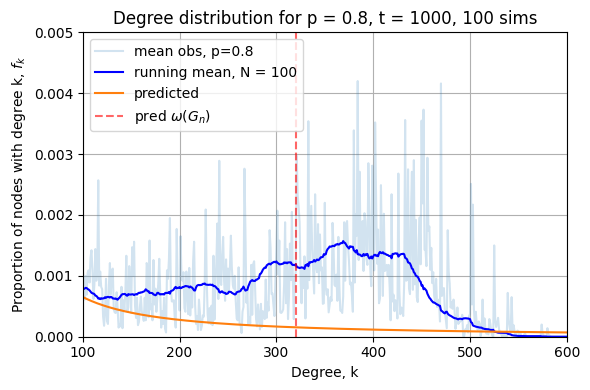

In [58]:
#plot only shows the long tail (k = 100 to k = 600)
#the new y-axis scaling allows us to see the behaviour in this region more clearly
p = 0.8
plt.figure(figsize=(6,4))
f_k = (fkArrUn(t, p, t + 1))
print("Total area of predicted degree distribution:", np.sum(f_k))
#for i in range(0, sims):
#    plt.plot(degHistFullResults[i], alpha = 0.05) 
plt.plot(np.array(degHistMean) / t, label =f"mean obs, p={p}", alpha = 0.2)
plt.plot(np.array(degHistRunMean) / t, label =f"running mean, N = {window*2}", color = "b")
upper = (np.array(degHistMean) + np.array(degHistStd)) / t
lower = (np.array(degHistMean) - np.array(degHistStd)) / t
#plt.fill_between(np.linspace(0, 1000, 1000), lower, upper, alpha=0.25, label='±1 std dev')
plt.plot(f_k / t, label="predicted", color = "tab:orange")
plt.axvline(x = 319.89, color = "r", linestyle = "--", label = "pred $\omega(G_n)$", alpha = 0.6)
plt.legend()
plt.xlabel("Degree, k")
plt.ylabel("Proportion of nodes with degree k, $f_k$")
plt.title(f"Degree distribution for p = {p}, t = {t}, {sims} sims")
plt.grid(True)
plt.xlim(100, 600)
plt.ylim(0, 0.005)
plt.tight_layout()
plt.show()

Now we create a log-log plot for the degree distribution, with log-binning to reduce the skewing effect of large outliers. We need to account for outliers, as we know that for $p > 1/2$ that the edge number (and hence mean degree) is not self-averaging. So for simulations where the copying mechanism activates a lot for small $t$, we expect to see many nodes with high degree.

As explained earlier, we see that the presence of large cliques causes the frequency of high degree nodes to increase to the right of $k \approx 320$. Similarly, on our log-log plot, we see our observed degrees exceed our predicted $k^{-1/p}$ in this range. However, we see that our predicted stationary distribution still does a good job of approximating the degree distribution, even for values of p where it should not hold.

In [59]:
#log-log calculations for p=0.8, note that we are using log10 here for visualisation purposes
p = 0.8
pValues = [p]
degHistFullResults = {}
sims = 100
t = 1000
for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    edgeArray = []
    for i in range(1, sims + 1):
        with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
            G = pickle.load(f)
        degHist = np.array(nx.degree_histogram(G))
        l_diff = t - len(degHist)
        degHistPad = np.pad(degHist, (0, l_diff))
        degHistFullResults[i-1] = degHistPad

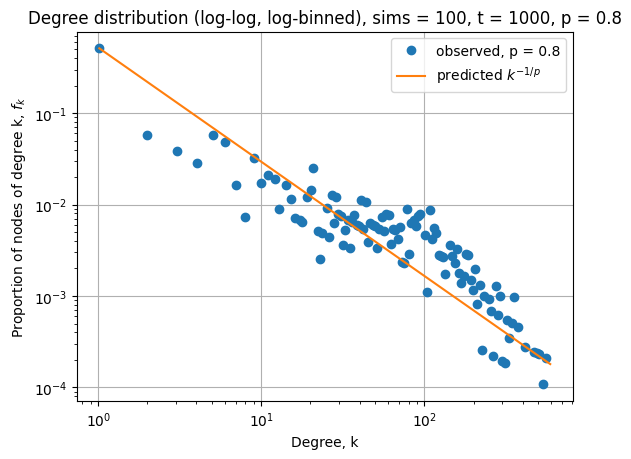

In [60]:
degHistTotals = np.zeros(t+1)
#totals the results from all our simulations
for i in range(0, sims):
    for k in range(0, t):
        degHistTotals[k] += degHistFullResults[i][k]

#sets up the log bins
bins = np.logspace(np.log10(1), np.log10(600), num=200)
hist, bin_edges = np.histogram(degHistTotals, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#plots data without line graph
plt.figure()
plt.loglog(bin_centers, hist, marker="o", linestyle="none", label=f"observed, p = {p}")

#Plots the predicted relationship. On a log-log plot, we expect the data to have a gradient of -1/p
#This is exactly the exponent of the stationary distribution
p = 0.8
pred = bin_centers ** (-1 / p)
pred = (hist[0] / pred[0]) * pred
plt.loglog(bin_centers, pred, label="predicted $k^{-1/p}$")

plt.xlabel("Degree, k")
plt.ylabel("Proportion of nodes of degree k, $f_k$")
plt.legend()
plt.grid()
plt.title(f"Degree distribution (log-log, log-binned), sims = {sims}, t = {t}, p = {p}")
plt.show()

## Mean Shortest Path Distance between pairs of nodes
Defining $d(u, v) = \text{shortest path distance from node $u$ to node $v$}$ and the expected shortest path length as $l_n = \mathbb{E}[d(u, v)]$, we derived the following recurrence relation $l_{n+1} = l_n + \frac{2(1 - p)}{n+1} + \frac{p}{n(n+1)} - \frac{pl_n}{n(n+1)}$ <br> 
which has the solution $l_n \sim 2(1-p)\log(n) + c$. In the RevTex submission, we posited that this gives a bound on the diameter, which should also grow like $D_n \sim (1-p)\log(n)$. 

However, this model does not satisfy the shrinking diameter behaviour that we see in many empirical dense networks (as in the Leskovec paper [3]). We hypothesise that a modified all-or-none model with second-neighbour copying would be better suited to model this behaviour, and we look into this in the second notebook, which shows the modified double copying all-or-none model.

In [61]:
#similar to the code to calculate the clique number over time (see documentation)
#takes samples of path length at regular intervals of [sampleTime]
p = 0.3
pValues = [p]
t = 1000
sims = 10
pathFullResults = {}
pathResults = {}
pathMedResults = {}

samples = 20
sampleTime = 50

for p in pValues:
    #for naming conventions
    pstr = str(p)[2:]
    order = int(np.floor(np.log10(abs(t))))
    lead = str(t)[0]
    tstr = str(lead) + "e" + str(order)
    pathArray = []
    #loads graph for each simulation
    for i in range(0, sims):
        with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i+1}.pkl", "rb") as f:
            G = pickle.load(f)
        Gsub = G.subgraph(1)
        subNodes = [1]
        pathArray = [0]
        for j in range(0, samples):
            for k in range(j * sampleTime + 2, (j + 1) * sampleTime + 2):
                subNodes.append(k)
            Gsub = G.subgraph(subNodes)
            #finds average shortest path length for each pair of nodes in Gsub
            pathArray.append(nx.average_shortest_path_length(Gsub))
        pathFullResults[i] = pathArray
    pathMeanArr, pathMedArr, pathStdArr = aonMeanStdCalc(pathFullResults, samples + 1, sims)
    pathResults[p] = pathMeanArr
    pathMedResults[p] = pathMedArr

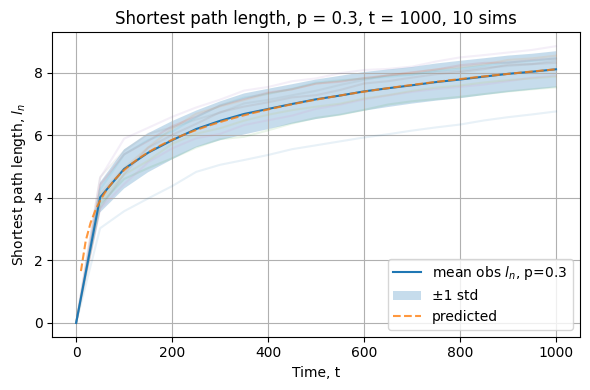

In [62]:
#code to plot the path length against the expected path length
#note that since we derive path length up to a constant, then the "normalisation step" nails down the 
#constant rather than a prefactor
plt.figure(figsize=(6,4))
pValues = [0.3]
#plots the path length against t for each simulation
for i in range(0, sims):
    plt.plot([i * sampleTime for i in range(0, samples + 1)], pathFullResults[i], alpha = 0.1)  
#plots the mean shortest path length
for p in pValues:
    plt.plot([i * sampleTime for i in range(0, samples + 1)], pathResults[p], label=f"mean obs $l_n$, p={p}")  
#plots the predicted path length, determining constant c using the mean shortest path length
upper = np.array(pathMeanArr) + np.array(pathStdArr)
lower = np.array(pathMeanArr) - np.array(pathStdArr)
plt.fill_between(np.linspace(0, 1000, samples + 1), lower, upper, alpha=0.25, label='±1 std')
p = 0.3
x = np.linspace(10, 1000, 100)
y = 2*(1-p)*np.log(x)
c = pathMeanArr[-1] - y[-1]
y += c
plt.plot(x, y, label="predicted", linestyle = "--", alpha = 0.8)
plt.xlabel("Time, t")
plt.ylabel("Shortest path length, $l_n$")
plt.title(f"Shortest path length, p = {p}, t = {t}, {sims} sims")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Assortativity
Defining $D_u(n)$ and $D_v(n)$ to be random variables representing the degrees of adjacent nodes u and v, we define the assortativity coefficient as <br>
$r_n = \frac{cov(D_u(n), D_v(n))}{\sigma_{D_u(n)}\sigma_{D_v(n)}} = \frac{cov(D_u(n), D_v(n))}{var(D_u(n))}$

#### Variance and Covariance
In our analytic analysis, we first found recurrence relations for the variance $V_n = var(D_u(n))$ and covariance $W_{n} = cov(D_u(n), D_v(n))$, as follows <br>
$V_{n+1} = (1+\frac{2p}{n})V_n + \frac{p\mathbb{E}[D_u(n)]+1}{n} \ - \frac{p^2\ \mathbb{E}[D_u(n)] + 2p \ \mathbb{E}[D_u(n)] + 1}{n^2}$ <br>
$W_{n+1} = (1+\frac{2p}{n})W_n + \frac{p(m_n+2)}{n} \ - \frac{p^2\ \mathbb{E}[D_u(n)] + 2p \ \mathbb{E}[D_u(n)] + 1}{n^2}$ <br>
However, we find that by solving for $\mathbb{E}[D_u(n)]$ and $m_n$, that $V_n$ and $W_n$ are actually of the same order, showing that $r_n \sim r_\infty(p)$. We prove that at the endpoints, $r_\infty = 0$, and show that for $0 < p < 1$ that assortativity is positive. 
This behaviour can be verified by numerical simulations below, showing $r_n$ at fixed n and varying p, showing that as we fix n for larger values, the assortativity converges.

Additionally, we can approximate the assortativity coefficient via the recurrence relations for variance and covariance but will not show that in this notebook.


In [63]:
#plots assortativity coefficient against p for varying values of n, shows how r_n converges
#also uses saved graphs (similar algorithm to the calculation for the clustering coefficient)
#(see documentation for the clustering coefficient to see how we get subgraphs for G_m (at lower tValues)

#initialisation for pValues, tValues
pValues = [i * 0.02 for i in range(0, 41)]
t = 1000
tValues = [30, 100, 300, 1000]
sims = 10
assFullResults = {}
assResults = {}

#for naming conventions
order = int(np.floor(np.log10(abs(t))))
lead = str(t)[0]
tstr = str(lead) + "e" + str(order)

#similar to clustering coefficient algorithm
for t in tValues:
    subNodes = [i for i in range(1, t + 1)]
    assFullResults[t] = {}
    assResults[t] = {}
    for p in pValues:
        #for naming conventions
        pstr = str(p)[2:]
        assArray = []
        for i in range(1, sims + 1):
            with open(f"AON\\{p}\\aonp{pstr}t{tstr}s{i}.pkl", "rb") as f:
                G = pickle.load(f)
            Gsub = G.subgraph(subNodes)
            assArray.append(nx.degree_assortativity_coefficient(Gsub))
        assFullResults[t][p] = assArray
        assResults[t][p] = np.nanmean(assArray)

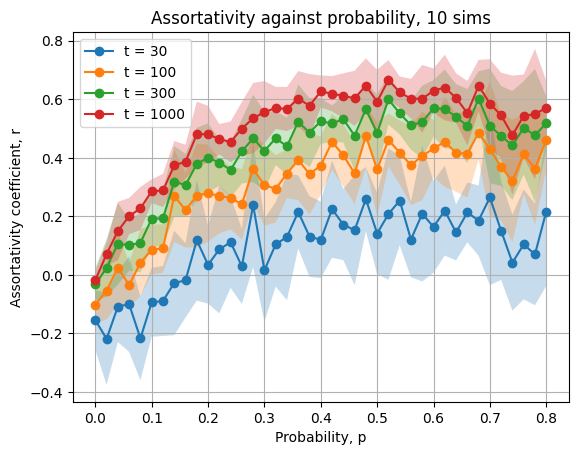

In [64]:
#code to plot the assortativity coefficient
#note that the convergence looks very different here, for low t, clustering coeff varies around C_inf
#we see assortativity approach r_inf from below, slowly converging to an "n-independent" function of p
#however, this still displays the convergent behaviour that we are looking for
means = {}
stds = {}
med = {}
lower = {}
upper = {}

pValues = [i * 0.02 for i in range(0, 41)]
tValues = [30, 100, 300, 1000]
for t in tValues:
    means[t] = []
    stds[t] = []
    med[t] = []
    for p in pValues:
        values = assFullResults[t][p]
        means[t].append(np.nanmean(values))
        stds[t].append(np.nanstd(values))
        med[t].append(np.nanmedian(values))

    means[t] = np.array(means[t])
    stds[t] = np.array(stds[t])
    med[t] = np.array(med[t])
    
    lower[t] = means[t] - stds[t]
    upper[t] = means[t] + stds[t]

for t in tValues:
    plt.plot(pValues, means[t], marker='o', label=f"t = {t}")
    #plt.plot(pValues, med[t], marker='o', label='med')
    plt.fill_between(pValues, lower[t], upper[t], alpha=0.25) #, label='±1 std dev')
plt.xlabel("Probability, p")
plt.ylabel("Assortativity coefficient, r")
plt.title(f"Assortativity against probability, {sims} sims")
plt.grid(True)
plt.legend()
plt.show()